In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_frame = pd.read_csv("health_risk_classification.csv")

In [3]:
data_frame.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


### bmi_score-->vucut skoru(zayifligina boyuna kilosuna gore)<br>blood_pressure-->kan basinci degisimi, dalgalanmasi<br>activity_level-->ne kadar aktif test edilen kisi <br>high_risk-->0:saglik riski yok ise, 1:saglik riski var ise

In [4]:
print(data_frame.info(),"\n",data_frame.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None 
          bmi_score  blood_pressure_variation  activity_level_index  \
count  1000.000000               1000.000000           1000.000000   
mean     -0.023702                  0.016769             -0.020771   
std       1.203694                  1.268761              1.392738   
min      -4.743951                 -2.587178             -4.999018   
25%      -0.796655                 -0.981320             -1.057938   
50%       0.142105                 -0.317137              0.204506   
75%       0.95622

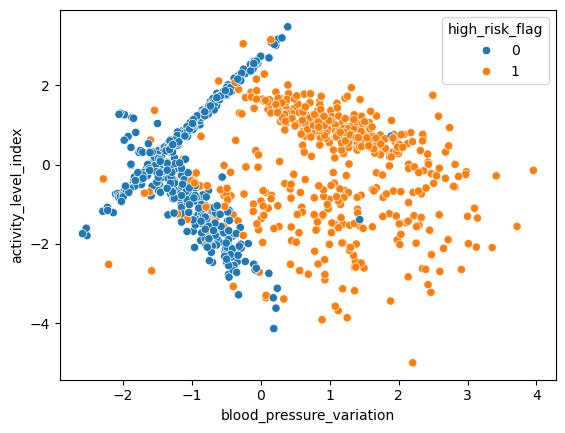

In [5]:
sns.scatterplot(x=data_frame["blood_pressure_variation"], y=data_frame["activity_level_index"], hue=data_frame["high_risk_flag"])
plt.show()

In [6]:
print(data_frame["high_risk_flag"].value_counts()) #dengeli bir data

high_risk_flag
0    502
1    498
Name: count, dtype: int64


In [7]:
X = data_frame.drop("high_risk_flag", axis=1)
y = data_frame["high_risk_flag"]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

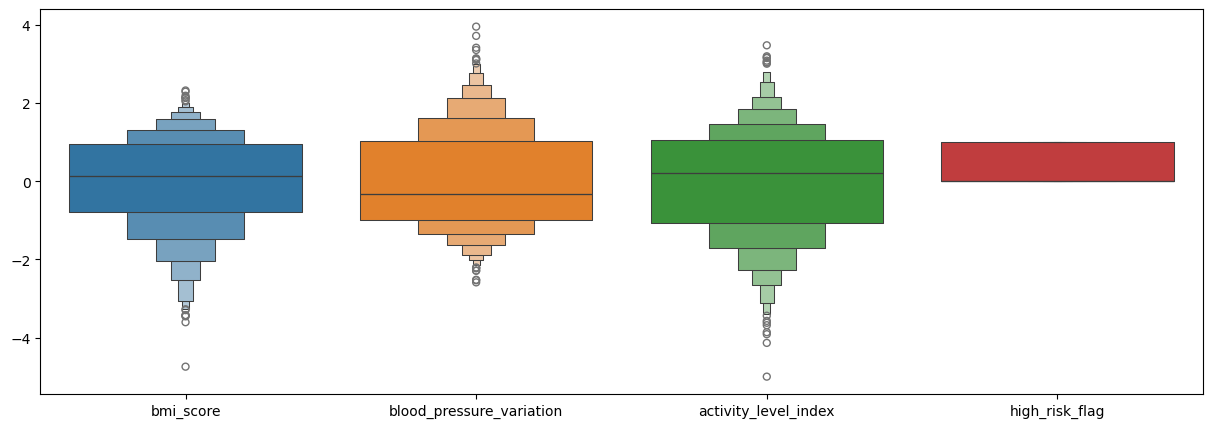

In [9]:
plt.figure(figsize=(15,5))
sns.boxenplot(data_frame)
plt.show()

### knn de scaling olayi onemlidir. Bu tabloya gore kullanmazsak da olur ama kullanalim

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [11]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [12]:
from sklearn.neighbors import KNeighborsClassifier #diyerek import edebiliriiiz

[sklearn/KNNClassifier dokumantasyonuna gitmek icin tiklayiniz..](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

### KNeighborsClassifier() diyip shift+tab yaparsak filan da bazi hiperparametreleri gorebiliriz. <br> +__n_neighbors__: Komsu sayisi. yani kac tane komsusuyla bu islemi yapacak onu belirleriz. default olarak 5'dir. <br>+__algorithm__-->{‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}, default=’auto’ seklinde kullanabiliriz<br>+__weight__-->__"uniform"__ dersen hangisinden fazla varsa o seciliyor zaten. __"distance"__ dersek de mesafe yakin olana daha fazla agirlik verir. yani mesafeye bakar ona gore kendince skor cikarir.<br>+__P__-->"1" yaparsak menhatten distance kullaniyor, "2" yaparsak oklid distance kullaniyor

In [13]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="auto")

In [14]:
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [15]:
y_pred = classifier.predict(X_test_scaler)

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [17]:
print("confusion matrix: \n\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("\n accuracy skore: ", accuracy_score(y_test, y_pred))

confusion matrix: 

 [[124   2]
 [ 10 114]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250


 accuracy skore:  0.952


In [18]:
classifier2 = KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree")
classifier2.fit(X_train_scaled, y_train)
y_pred2 = classifier2.predict(X_test_scaler)

print("confusion matrix: \n\n", confusion_matrix(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print("\n accuracy skore: ", accuracy_score(y_test, y_pred2))

confusion matrix: 

 [[124   2]
 [ 10 114]]
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250


 accuracy skore:  0.952


## GRID search cv deneyelim

In [19]:
parametreler = {
    "n_neighbors" : [1,2,3,4,5,6,7,8,9],
    "weights" : ["uniform", "distance"],
    "algorithm" : ["auto", "ball_tree", "kd_tree"]
}

In [20]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametreler, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [21]:
print("En İyi Hiperparametreler:", grid_search.best_params_)
print("En İyi Skor (Doğruluk):", grid_search.best_score_)

En İyi Hiperparametreler: {'algorithm': 'auto', 'n_neighbors': 4, 'weights': 'uniform'}
En İyi Skor (Doğruluk): 0.9493333333333333


# Regresyon kismina gecelim

In [22]:
df_reg=pd.read_csv("house_energy_regression.csv")

In [23]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


### __daily_energy_consumption_kwh__-->kw cinsinden gunluk energy harcamasi<br>__avg_indoor_temp_change__-->evin icindeki hava durumunun degisimi<br>__outdoor_humidity_level__-->evin disindaki nem seviyesini gosteriyor

In [24]:
print(df_reg.info(), "\n", df_reg.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB
None 
        avg_indoor_temp_change  outdoor_humidity_level  \
count             1000.000000             1000.000000   
mean                 0.033186                0.056982   
std                  0.961603                1.014959   
min                 -3.241267               -2.940389   
25%                 -0.611581               -0.651418   
50%                  0.036043                0.047742   
75%                  0.648317                0.714886   
max                  3.078881                3.852731   

       daily_energy_consumption_kwh  


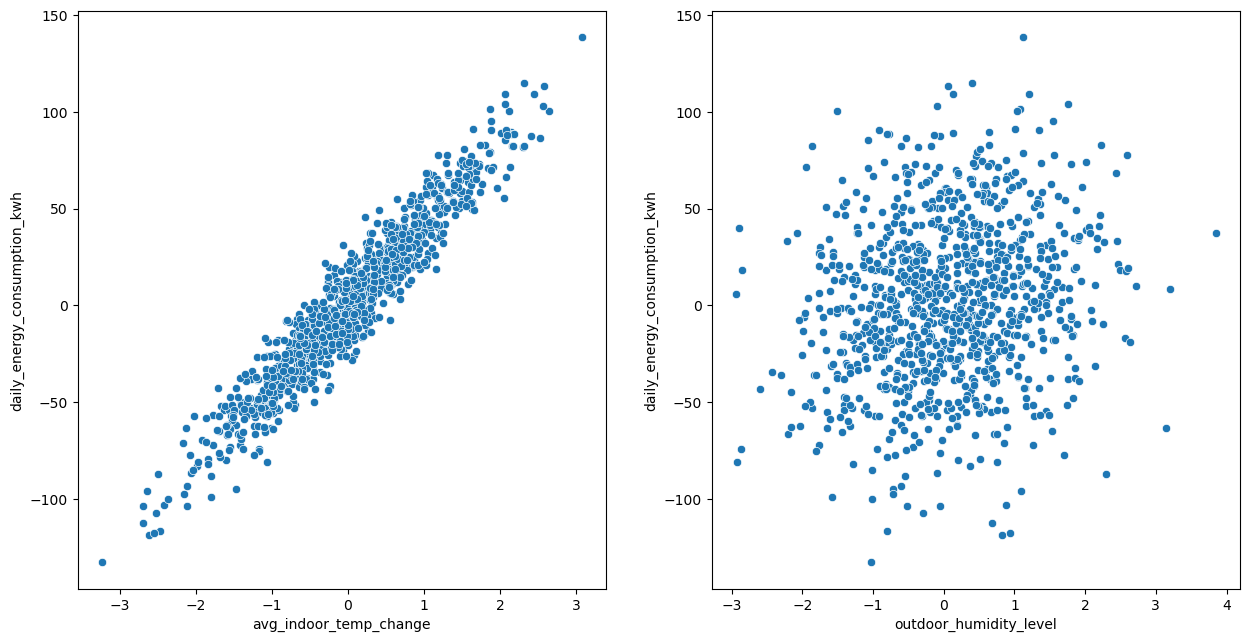

In [25]:
plt.figure(figsize=(15,7.5))
plt.subplot(1,2,1)
sns.scatterplot(x=df_reg["avg_indoor_temp_change"], y=df_reg["daily_energy_consumption_kwh"])
plt.subplot(1,2,2)
sns.scatterplot(x=df_reg["outdoor_humidity_level"], y=df_reg["daily_energy_consumption_kwh"])
plt.show()

In [26]:
X = df_reg.drop("daily_energy_consumption_kwh", axis=1)
y = df_reg["daily_energy_consumption_kwh"]

In [27]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.25, random_state=15)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.neighbors import KNeighborsRegressor

[sklearn/KNNClassifier dokumantasyonuna gitmek icin tiklayiniz..](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

In [30]:
regressor = KNeighborsRegressor(n_neighbors=5, algorithm="auto" ) #ayni parametreler classifierde vardi farkli bisi yok!

In [31]:
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [32]:
y_pred = regressor.predict(X_test_scaled)


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
print("r2 score: ", r2_score(y_test, y_pred))
print("mae: ", mean_absolute_error(y_test, y_pred))
print("mse: ", mean_squared_error(y_test, y_pred))

r2 score:  0.9183109118983248
mae:  9.228754406902722
mse:  135.6610827281179


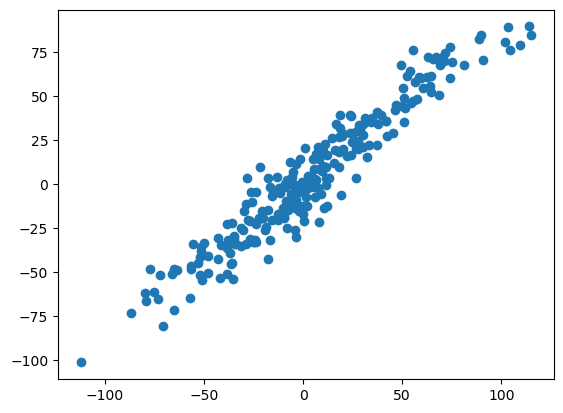

In [36]:
plt.scatter(y_test, y_pred)
plt.show()